# PID Controller Demo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

## Discretized PID Equation

PID controller can be described by this equation
$$ u(t) = K_{p}e(t) + K_{i}\int_{0}^{t}e(\tau)d\tau + K_{d}\frac{d }{dt}e(t) \tag{1}$$

Where $K_{p}$, $K_{i}$, and $K_{d}$ are PID parameter named proportional gain, integral gain, and derivative gain respectively.

Let's define $T_{s}$ as a time step or sampling interval

The linear/proportional terms can be discretized into 
$$ e(t) \rightarrow e[k] \tag{2} $$

Using trapezoidal rule, the integral becomes
$$  \int_{t_{k}-1}^{t_{k} }e(\tau)d\tau \rightarrow \frac{T_{s} }{2} (e_{i}[k] + e[k-1]) $$
By definition, the integral can be calculated as
$$ \int_{0}^{t_{k} }e(\tau)d\tau = \int_{0}^{t_{k}-1 }e(\tau)d\tau + \int_{t_{k}-1 }^{t_{k} }e(\tau)d\tau $$
Define $I[k]$ as the discretized version of $\int_{0}^{t_{k} }e(\tau)d\tau$, then we get
$$ \int_{0}^{t_{k} }e(\tau)d\tau \rightarrow I[k] = I[k-1] + \frac{T_{s} }{2} (e_{i}[k] + e[k-1]) \tag{3}$$

For derivative terms, we can use backward difference approximation, so we can get
$$ \frac{d }{dt}e(t) \rightarrow e_{d}[k] =  \frac{e[k]-e[k-1]}{T_{s} } \tag{4}$$


Substitute equations 2,3,4 into 1 then we can get

$$ u[k] = K_{p}e[k] + K_{i} (I[k-1] + \frac{T_{s} }{2} (e_{i}[k] + e[k-1])) + K_{d} \frac{e[k]-e[k-1]}{T_{s} } \tag{5}$$

In [42]:
time = 0
integral = 0
time_prev = -1e-6
e_prev = 0

def PID(Kp, Ki, Kd, setpoint, measurement):
    global time, integral, time_prev, e_prev

    # Value of offset - when the error is equal zero
    offset = 320
    
    # PID calculations
    e = setpoint - measurement
    Ts = time - time_prev  # Time step (delta t)
    
    # Avoid division by zero (if Ts == 0, skip D term)
    if Ts <= 0:
        Ts = 1e-5  # Small value to prevent numerical issues
    
    # Proportional term
    P = Kp * e
    
    # Integral term (Trapezoidal integration)
    integral = integral + (Ki * Ts / 2) * (e + e_prev)  # Correct averaging
    
    # Derivative term (Backward difference)
    D = Kd * (e - e_prev) / Ts
    
    # Calculate manipulated variable (MV)
    MV = offset + P + integral + D
    
    # Update stored data for next iteration
    e_prev = e
    time_prev = time
    
    return MV

## Plant Definition

In this example we use the plant described in [this link](https://softinery.com/wp-content/uploads/blog/process-control/Lecture_4.pdf)

The plant can be described by this equation

$$ \frac{dT}{dt} = \frac{1}{1 + \varepsilon} \left[ \frac{1}{\tau} (T_{f}-T) + Q(T_{q}-T)   \right] \tag{6}$$

The above ODE can be solved using fourth order runge kutta methods:

$$ y_{i+1} = y_{i} + \frac{1}{6} (k_{1}+4k_{2}+k_{3})h \tag{7}$$

$$k_{1} = f(x_{i},y{i})$$

$$k_{2} = f\left( x_{i} + \frac{1}{2}h, y{i} + \frac{1}{2}k_{1}h \right)$$

$$k_{3} = f(x_{i}+h, y_{i} - k_{1}h + 2 k_{2}h) $$


In [43]:
def system(t, temp, Tq):
    epsilon = 1
    tau = 4
    Tf = 300
    Q = 2
    dTdt = 1/(tau*(1+epsilon)) * (Tf-temp) + Q/(1+epsilon)*(Tq-temp)
    return dTdt

def approximate_ode_with_forth_order_runge_kutta(t, temp, Tq, h)->float:
    k1 = system(t, temp, Tq)
    k2 = system(t + 0.5*h, temp + 0.5*k1*h, Tq)
    k3 = system(t + h, temp - k1*h + 2*k2*h, Tq)
    return temp + (1/6) * (k1 + 4*k2 + k3) * h

def solve_ode_with_forth_order_runge_kutta(timespan: np.ndarray, T0: float, Tq: float)->np.ndarray:
    h = timespan[1] - timespan[0]
    T = np.empty(len(timespan))
    T[0] = T0
    for idx in range(1, len(timespan)):
        t = timespan[idx-1]
        T[idx] = approximate_ode_with_forth_order_runge_kutta(t, T[idx-1], Tq, h)
    return T

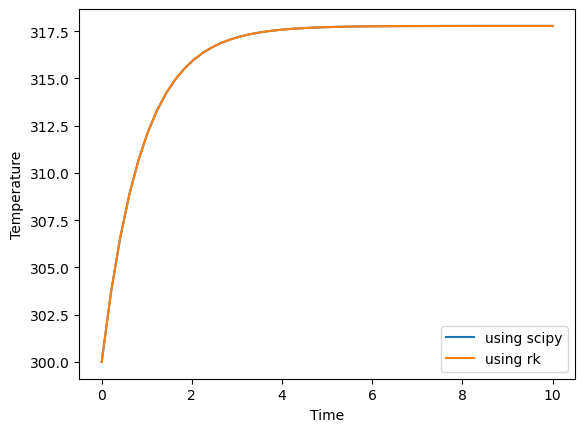

In [46]:
tspan = np.linspace(0,10,50)
Tq = 320.0
# HOMEWORK 1: EXPLAIN THIS ONE
sol = odeint(system,300, tspan, args=(Tq,), tfirst=True)
# HOMEWORK 2: Solve the system using numerical method
sol_rk = solve_ode_with_forth_order_runge_kutta(tspan, 300.0, Tq)

plt.xlabel('Time')
plt.ylabel('Temperature')
plt.plot(tspan,sol,label="using scipy")
plt.plot(tspan,sol_rk, label="using rk")
plt.legend()
plt.show()

## DO NOT TOUCH THIS

Text(0, 0.5, 'Temperature')

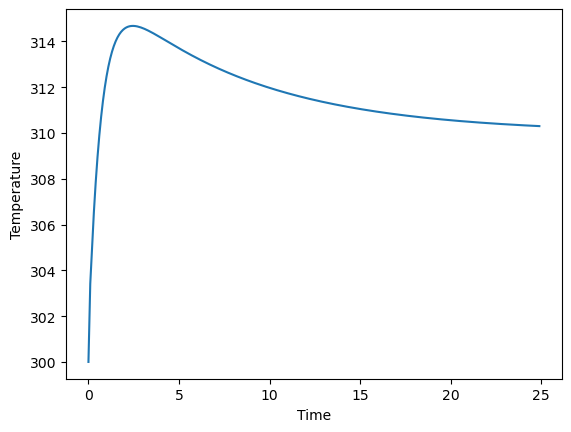

In [45]:
# number of steps
n = 250

time_prev = 0.0
y0 = 300
deltat = 0.1
y_sol = [y0]
t_sol = [time_prev]

# Tq is chosen as a manipulated variable
Tq = 320.0,

q_sol = [Tq[0]]
setpoint = 310
integral = 0
for i in range(1, n):
    time = i * deltat
    tspan = np.linspace(time_prev, time, 10)
    Tq = PID(0.6, 0.2, 0.1, setpoint, y_sol[-1]),
    yi = odeint(system,y_sol[-1], tspan, args = Tq, tfirst=True)
    t_sol.append(time)
    y_sol.append(yi[-1][0])
    q_sol.append(Tq[0])
    time_prev = time

plt.plot(t_sol, y_sol)
plt.xlabel('Time')
plt.ylabel('Temperature')